# Visualisation of 1D model output

**Date:** 2026-03-09

**Authors:** Damien Bouffard

**Summary:** This notebook provides tools to download, load, save and visualise 1D lake model output (Simstrat-like `T_out.dat`).

## Before You Start:

**No Python knowledge needed!** Just follow these steps:
1. Run each cell in order (click the ▶️ button or press Shift+Enter)
2. Change the values in the examples to customize your visualizations
3. Look for the sections marked "👉 CUSTOMIZE HERE" to modify parameters

## Content:

This notebook helps you create visualizations of lake temperatures. You can:

1. **Download and save 1D model output** Using  your own local simulation
2. **Plot time series** Showing how temperature changes over time at a specific location
3. **Plot temperature heatmap** Ploting temperature heatmap (depth vs time)
4. **Plot climatology** Showing how the temperature evolves over a year
5. **Compare lakes or scenario** Plotting the difference in temperature between 2 lakes or two scenario

## Available Functions:

- `df = load_lake_data(model='simstrat',lake='aegeri',...)`- load online or local model output, save the dataset.
- `plot_temperature_heatmap(df, years=None, ...)` — plot temperature heatmap (depth vs time).
- `plot_temperature_at_depth(df, depth, ...)` — extract and plot a time series at the nearest available depth (with aggregation options).
- `plot_temperature_climatology(df, depth, ...)` — compute and plot daily-of-year climatology (mean, std, min, max) with optional baseline-year overlay.
- `compare_heatmaps(path1, path2, ...)` — load two site outputs and plot their difference heatmap (restricted to shallowest system).
- `plot_two_sites_at_depth(path1, path2, depth, ...)` — extract and plot aligned time series from two sites at a given depth.



---

## STEP 1: Import Required Libraries
## ESSENTIAL STEP


In [1]:
# Import standard Python libraries for data handling and visualization
import os               # Used to work with files and folders
import numpy as np      # Used for mathematical operations and working with arrays of numbers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # Used to create plots and visualizations
from datetime import datetime, timezone, timedelta  # Used to work with dates and times
import json             # Used to work with JSON data format
import requests         # Used to download data from the internet


# Import custom functions specifically designed for Alplakes data
# These functions do the heavy lifting for fetching and plotting data
from functions_1D import plot_temperature_heatmap, plot_temperature_at_depth, plot_temperature_climatology, compare_heatmaps, plot_two_sites_at_depth
from functions_1D import  generate_path_API_1D, read_API_1D_to_dataframe, fetch_API_1D_chunked, load_lake_data

print("✓ All libraries loaded successfully!")
print("You're ready to start visualizing lake data.")

✓ All libraries loaded successfully!
You're ready to start visualizing lake data.


---
# Step 2
## Loading data (locally on online)


**Example**
```python
df = load_lake_data(
    model='simstrat',           
    lake='Morat',              # 👉 change lake (check used name on Alplakes)
    start='198101010000',       # 👉 start of model output YYYYMMDDHHMMSS String, 12 digits
    stop='202512010000',        # 👉 end of model output YYYYMMDDHHMMSS String, 12 digits 
    variables="T",
    local_path='../data/Morat_baseline/T_out.dat',  # 👉 if use of local data, indicate the path and the name here
)
```

In [3]:
df = load_lake_data(
    model='simstrat',           
    lake='Morat',              # 👉 change lake (check used name on Alplakes)
    start='198101010000',       # 👉 start of model output YYYYMMDDHHMMSS String, 12 digits
    stop='202512010000',        # 👉 end of model output YYYYMMDDHHMMSS String, 12 digits 
    variables="T",
    local_path='../data/Morat_baseline/Results/T_out.dat',  # 👉 if use of local data, indicate the path and the name here
)


Loading data from local file: ../data/Morat_baseline/Results/T_out.dat
✓ Loaded 16493 rows from DAT file
✓ Filtered to date range: 16404 rows between 1981-01-01 and 2025-12-01


---
# Step 3
## data visualisation 

---
### Case 1 ploting Heatmap

**Example**
```python
plot_temperature_heatmap(
    df, 
    years=None,         # 👉 change time range years = (2010,2020) or years = 2024
    cmap='viridis',     # 👉 change colormap 'turbo', 'virdis', 'thermal etc see https://matplotlib.org/stable/users/explain/colors/colormaps.html 
    vmin=None,          # 👉 adapt lower boundary  vmin = None or vmin = 0
    vmax=None,          # 👉 adapt upper boundary  vmax = None or vmax = 25
    figsize=(14,6),     # 👉 adapt figure size (in inches 1in = 2.54cm)
    n_xticks=10,        # 👉 max number of x ticks to show
    #savepath='../figures/heatmap_murten.png'       # 👉 option to save the figure (None or '../figures/')
    )    
```

<Axes: title={'center': 'Temperature  (All data)'}, xlabel='Date', ylabel='Depth (m)'>

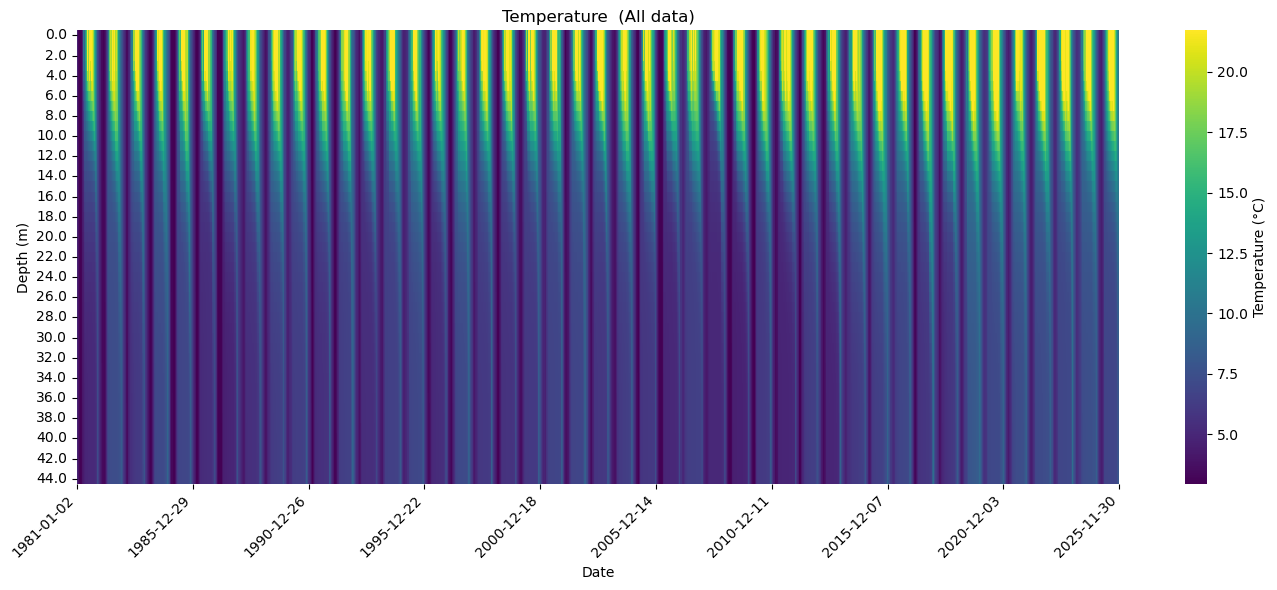

In [4]:
plot_temperature_heatmap(
    df, 
    years=None,         # 👉 change time range years = (2010,2020) or years = 2024
    cmap='viridis',     # 👉 change colormap 'turbo', 'virdis', 'thermal etc see https://matplotlib.org/stable/users/explain/colors/colormaps.html 
    vmin=None,          # 👉 adapt lower boundary  vmin = None or vmin = 0
    vmax=None,          # 👉 adapt upper boundary  vmax = None or vmax = 25
    figsize=(14,6),     # 👉 adapt figure size (in inches 1in = 2.54cm)
    n_xticks=10,        # 👉 max number of x ticks to show
    #savepath='../figures/heatmap_murten.png'       # 👉 option to save the figure (None or '../figures/')
    )    
#Examples.
#  plot_temperature_heatmap(df)
#  plot_temperature_heatmap(df, years=2024)
#  plot_temperature_heatmap(df, years=2024) 
# plot_temperature_heatmap(df, years=(2010,2020))  



---
### Case 2. Plotting time serie at one depth

***Example***
```python
plot_temperature_at_depth(
    df,
    depth = 0,        # 👉 change depth depth = 0 (positive values)
    agg = 'daily',    # 👉 change temporal aggregation, agg = 'daily', 'monthly' ,'yearly'  on none
    method = 'mean',  # 👉 change aggregation method "mean" or "median"
    figsize = (12,4), # 👉 adapt figure size (in inches 1in = 2.54cm)
    savepath = None   # 👉 option to save the figure (None or '../figures/temperature_Xm_murten.png')
    )
```

<Axes: title={'center': 'Temperature at depth ~0.0 m'}, xlabel='Date', ylabel='Temperature (°C)'>

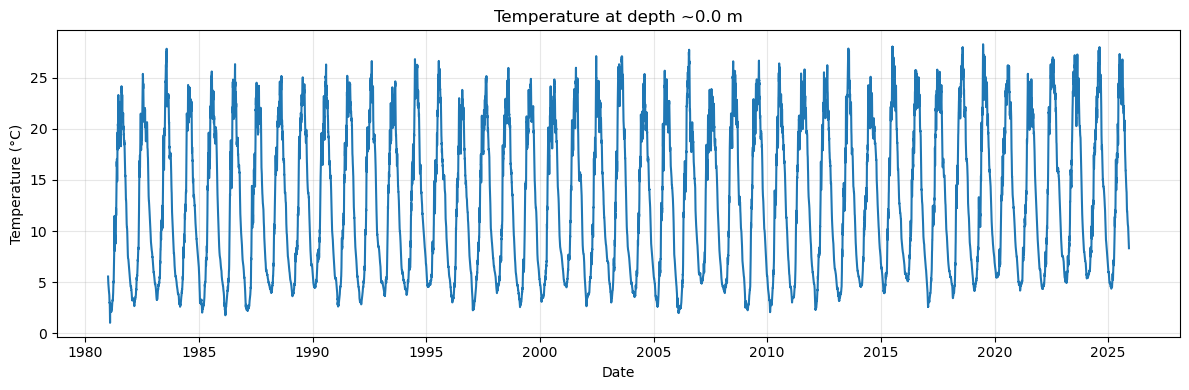

In [5]:
# plot_temperature_at_depth(df, depth=1.0, agg='daily')  # 👉 select depth, # 👉 change averaging , 'daily', 'monthly' ,'yearly'  or none (then remove)
plot_temperature_at_depth(
    df,
    depth = 0,        # 👉 change depth depth = 0 (positive values)
    agg = 'daily',    # 👉 change temporal aggregation, agg = 'daily', 'monthly' ,'yearly'  on none
    method = 'mean',  # 👉 change aggregation method "mean" or "median"
    figsize = (12,4), # 👉 adapt figure size (in inches 1in = 2.54cm)
    savepath = None   # 👉 option to save the figure (None or '../figures/temperature_Xm_murten.png')
    )


#plot_temperature_at_depth(df, depth=0)  

---
### Case 3. Ploting climatology figure at a given depth

**Example**
```python
ax, clim = plot_temperature_climatology(
    df, 
    depth = 0,               # 👉 change depth depth = 0 (positive values)   
    period=None,             # 👉 change time range years = (2010,2020) or None
    baseline_year=None,      # 👉 Assign a reference year baseline_year = 2013 or None
    method='mean',           # 👉 Aggregation method 'mean' or 'median'
    figsize=(12,5),          # 👉 adapt figure size (in inches 1in = 2.54cm)
    savepath=None            # 👉 option to save the figure (None or '..figures/climatology_murten.png')
    )
```


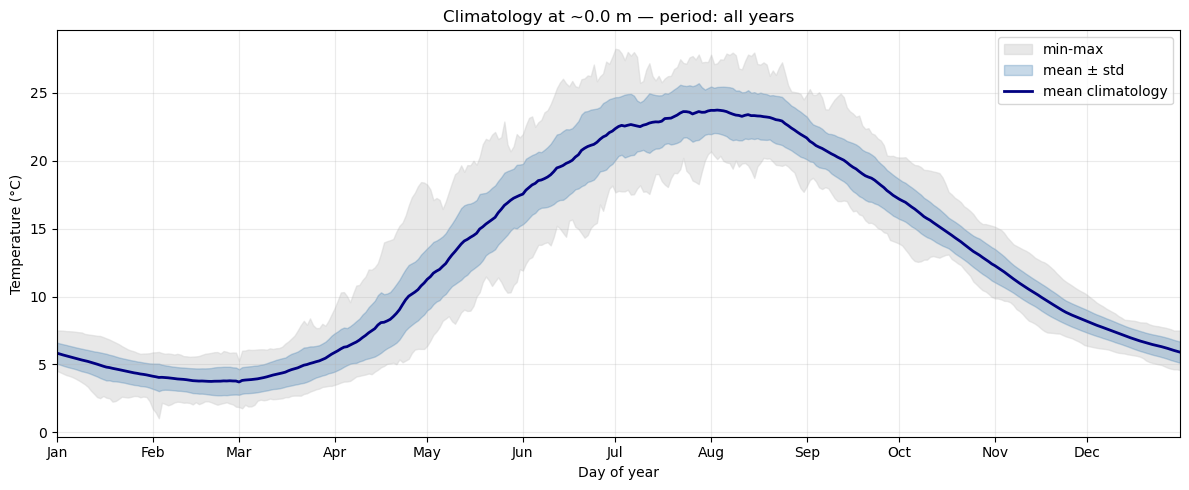

In [6]:
ax, clim = plot_temperature_climatology(
    df, 
    depth = 0,               # 👉 change depth depth = 0 (positive values)   
    period=None,             # 👉 change time range years = (2010,2020) or None
    baseline_year=None,      # 👉 Assign a reference year baseline_year = 2013 or None
    method='mean',           # 👉 Aggregation method 'mean' or 'median'
    figsize=(12,5),          # 👉 adapt figure size (in inches 1in = 2.54cm)
    savepath=None            # 👉 option to save the figure (None or '..figures/climatology_murten.png')
    )



---
### Case 4. Plot the difference between two simulations  as heatmap

For this case, you need to have 'T_out.dat' saved in your repository. For this you can either run simstrat with the setting you are interested in or download the output from the online simulation here https://www.alplakes.eawag.ch/downloads 

Comparison is restricted vertically to the maximum depth of the shallower system (by magnitude).

Only overlapping depths and times are used to compute the difference to avoid large NaN areas.

**Example**
```python
(ax, f) = compare_heatmaps(
    'data/Morat_deep_connection',           # 👉  path for first model output -- there should be a file T_out.dat in this folder         
    'data/Morat_baseline',     # 👉  path for second model output -- there should be a file T_out.dat in this folder
    years=(2010, 2020),      # 👉 change time range years = (2010,2020) 
    cmap='RdBu_r',           # 👉 change colormap 'turbo', 'virdis', 'thermal etc see https://matplotlib.org/stable/users/explain/colors/colormaps.html 
    figsize=(14,6),          # 👉 adapt figure size (in inches 1in = 2.54cm)
    n_xticks=10,             # 👉 max number of x ticks to show
    savepath=None            # 👉 option to save the figure (None or '../figures/comparison_lakeX_lakeY.png')
)    
```

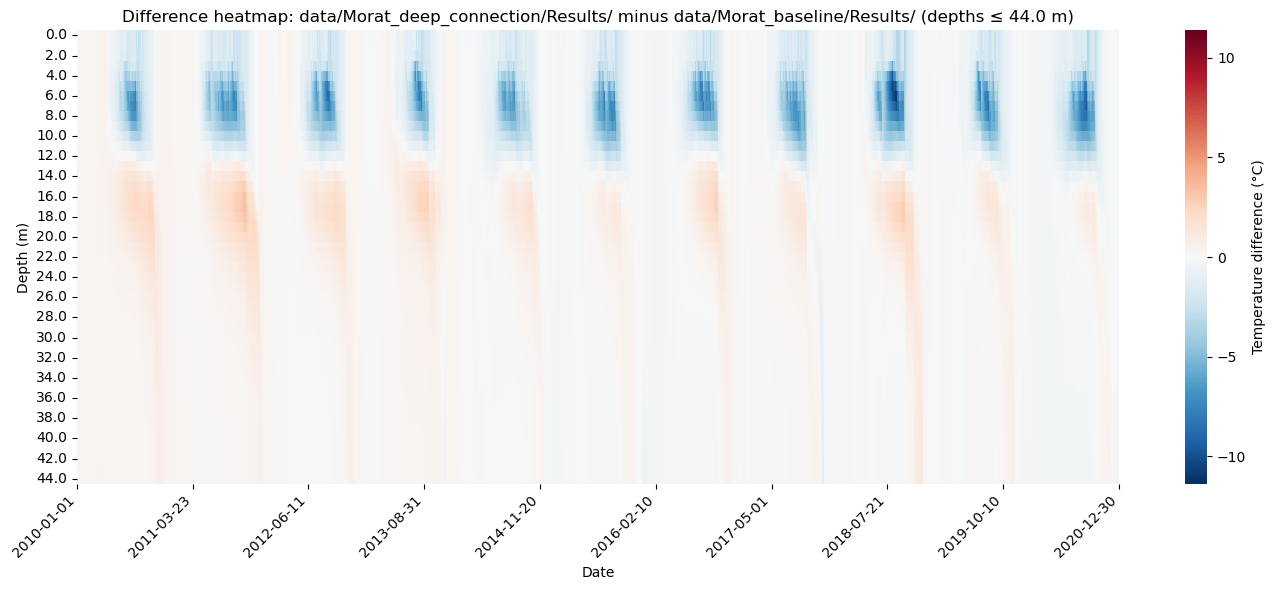

In [8]:
(ax, f) = compare_heatmaps(
    'data/Morat_deep_connection/Results/',           # 👉  path for first model output -- there should be a file T_out.dat in this folder         
    'data/Morat_baseline/Results/',     # 👉  path for second model output -- there should be a file T_out.dat in this folder
    years=(2010, 2020),      # 👉 change time range years = (2010,2020) 
    cmap='RdBu_r',           # 👉 change colormap 'turbo', 'virdis', 'thermal etc see https://matplotlib.org/stable/users/explain/colors/colormaps.html 
    figsize=(14,6),          # 👉 adapt figure size (in inches 1in = 2.54cm)
    n_xticks=10,             # 👉 max number of x ticks to show
    savepath=None            # 👉 option to save the figure (None or '../figures/comparison_lakeX_lakeY.png')
)    



---
### Case 5. Plot two simulations at a specific depth

Only overlapping depths and times are used to compute the difference to avoid large NaN areas.

**Example**
```python
ax, df = plot_two_sites_at_depth(
    'data/Geneva',              # 👉  path for first model output -- there should be a file T_out.dat in this folder
    'data/Upper_Lugano',        # 👉  path for second model output -- there should be a file T_out.dat in this folder
    depth=10,                   # 👉 change depth of investigation 
    years=(2000,2020),          # 👉 change time range years = (2010,2020) 
    agg='monthly',              # 👉 change temporal aggregation, agg = 'daily', 'monthly' ,'yearly'  on none
    savepath='figures/compare_10m.png' # 👉 option to save the figure (None or '../figures/comparison_lakeX_lakeY_Zm.png')
)
```

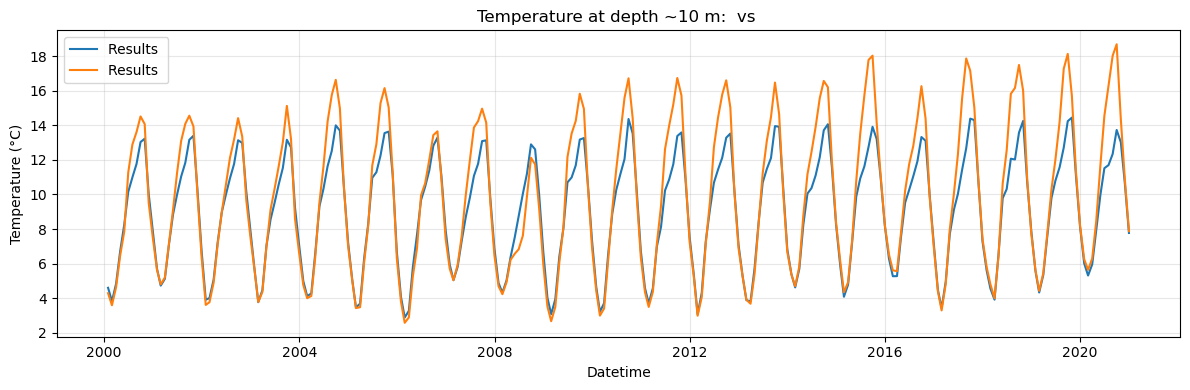

In [9]:
# Example usage:
ax, df = plot_two_sites_at_depth(
    'data/Morat_deep_connection/Results/',              # 👉  path for first model output -- there should be a file T_out.dat in this folder
    'data/Morat_baseline/Results/',        # 👉  path for second model output -- there should be a file T_out.dat in this folder
    depth=10,                   # 👉 change depth of investigation 
    years=(2000,2020),          # 👉 change time range years = (2010,2020) 
    agg='monthly',              # 👉 change temporal aggregation, agg = 'daily', 'monthly' ,'yearly'  on none
    savepath='figures/compare_10m.png' # 👉 option to save the figure (None or '../figures/comparison_lakeX_lakeY_Zm.png')
)